In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import optax
import matplotlib.pyplot as plt
import jax
from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [3]:
from typing import Optional
from jaxtyping import ArrayLike, Bool, Float
import warnings

In [4]:
def func(x):
    """Latent function."""
    return 1.0 * jnp.sin(x * 3 * jnp.pi) + \
           0.3 * jnp.cos(x * 9 * jnp.pi) + \
           0.5 * jnp.sin(x * 7 * jnp.pi)


# Number of training examples
n = 100

# Number of inducing variables
m = 30

# Noise
sigma_y = 0.2

# Noisy training data
X = jnp.linspace(-1.0, 1.0, n).reshape(-1, 1)
y = func(X) + sigma_y * random.normal(random.PRNGKey(0), shape=(n, 1))

# Test data
X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
f_true = func(X_test)

# Inducing inputs
X_m = jnp.linspace(-0.4, 0.4, m).reshape(-1, 1)

In [5]:
X_test.shape, f_true.shape

((1000, 1), (1000, 1))

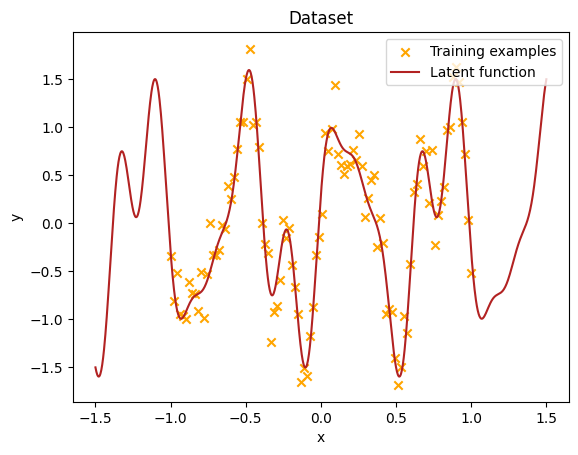

In [6]:
plt.scatter(X, y, label='Training examples', marker='x', color='orange')
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)
plt.title('Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

In [7]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared
num_inducing_points = 30
initial_inducing_points = jnp.linspace(X.min(), X.max(), num=num_inducing_points, endpoint=True)#[:,jnp.newaxis]
kernel_fn = ExpSquared

In [8]:
params = {'kernel': {'coefficient': jnp.array(0.9, dtype=jnp.float64), 'log_scale': jnp.array(0.0, dtype=jnp.float64)}, 'mean': {}, 'likelihood':{'log_diag': jnp.array(-2.5, dtype=jnp.float64),}, 'inducing_point_locations':jnp.array(initial_inducing_points, dtype=jnp.float64)}

In [9]:
from jax_mc_pilco.model_learning.gp.gaussian_process import SparseVariationalGaussianProcess, svgp_fit

In [10]:
gp = SparseVariationalGaussianProcess(kernel_fn,X,y,num_inducing_points,params)

In [11]:
%time
gp = svgp_fit(gp)

CPU times: user 2 µs, sys: 1e+03 ns, total: 3 µs
Wall time: 7.15 µs


In [12]:
params

{'kernel': {'coefficient': Array(0.9, dtype=float64),
  'log_scale': Array(0., dtype=float64)},
 'mean': {},
 'likelihood': {'log_diag': Array(-2.5, dtype=float64)},
 'inducing_point_locations': Array([-1.        , -0.93103448, -0.86206897, -0.79310345, -0.72413793,
        -0.65517241, -0.5862069 , -0.51724138, -0.44827586, -0.37931034,
        -0.31034483, -0.24137931, -0.17241379, -0.10344828, -0.03448276,
         0.03448276,  0.10344828,  0.17241379,  0.24137931,  0.31034483,
         0.37931034,  0.44827586,  0.51724138,  0.5862069 ,  0.65517241,
         0.72413793,  0.79310345,  0.86206897,  0.93103448,  1.        ],      dtype=float64)}

In [13]:
%%time
f_test, f_test_cov = gp.predict(X_test)

ValueError: Incompatible shapes for broadcasting: shapes=[(1000,), (1000, 100)]

In [14]:
X_test.shape, X.shape

((1000, 1), (100, 1))

In [15]:
mean = gp.mean(**gp.params["mean"])

In [19]:
jnp.atleast_2d(mean(X_test)).shape

(1, 1000)

In [14]:
%%time
X_test_new = np.linspace(-1.5, 1.5, 2500).reshape(1, -1)
f_t, f_t_cov = gp.predict(X_test_new)

CPU times: user 306 ms, sys: 23.5 ms, total: 329 ms
Wall time: 305 ms


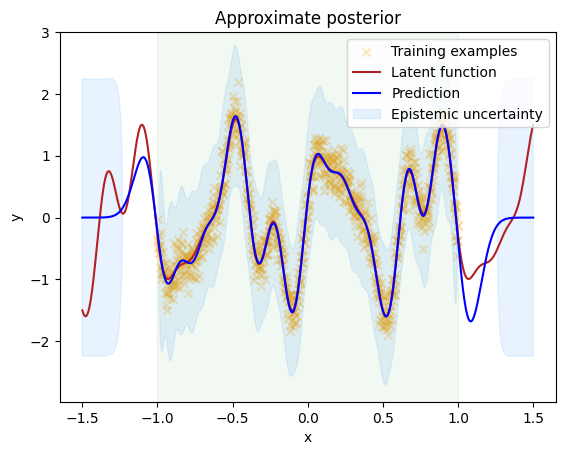

In [17]:
f_test_var = jnp.diag(f_test_cov)
f_test_std = jnp.sqrt(f_test_var)

plt.scatter(X, y, label='Training examples', marker='x', color='orange', alpha=0.25)
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)

plt.plot(X_test, f_test, label='Prediction', c='blue')
plt.fill_between(X_test.ravel(), 
                 f_test.ravel() + 2 * f_test_std, 
                 f_test.ravel() - 2 * f_test_std,
                 label='Epistemic uncertainty',
                 color='dodgerblue', alpha=0.1)
plt.title('Approximate posterior')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(None, 3.0)
plt.legend();
plt.axvspan(X.min(),X.max(),color='green',alpha=0.05)